# 장르/태그 선별 및 유저 선호도 벡터 생성

정제된 데이터를 기반으로 다음을 수행합니다.

1. **핵심 장르 선별** — 실제 게임 장르만 채택 (소프트웨어/툴 카테고리 제외)
2. **핵심 태그 선별** — 선별 기준(중복 제거 → 후보군 빈도 분포 확인 → Top-N 채택)을 시각적으로 검증하며 30개/50개 두 버전 생성
3. **원핫 인코딩** — 게임 단위로 선별된 장르/태그를 원핫 벡터화
4. **유저 선호도 벡터 생성** — 유저가 보유한 게임들의 `log(playtime+1)` 가중합으로 장르/태그 선호도 벡터 산출

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings, os

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_data.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"유저 수: {df['steamid'].nunique():,} / 게임 수: {df['appid'].nunique():,}")
df.head(2)

Shape: 26,340 rows x 17 cols
유저 수: 878 / 게임 수: 3,564


,steamid,appid,game_name,playtime_hours,recent_playtime_hours,genre,tags,steam_categories,total_reviews,positive_reviews,negative_reviews,rating_by_reviews,recommendations,metacritic,release_date,price(원),has_metacritic
0,76561199478662488,105600,Terraria,359.42,0.35,"Action, Adventure, Indie, RPG","Open World Survival Craft, Sandbox, Survival, ...","Single-player, Multi-player, PvP, Online PvP, ...",1546282,1505737,40545,97.38,1232905,83.0,2011-05-16,11000.0,1
1,76561199478662488,1281930,tModLoader,357.25,0.35,"Action, Adventure, Indie, RPG, Free To Play","Adventure, Free to Play, Action, Indie, RPG, M...","Single-player, Multi-player, PvP, Online PvP, ...",379134,368235,10899,97.13,0,NaN,2020-05-16,0.0,0


In [8]:
def parse_list(s):
    """콤마로 구분된 문자열을 리스트로 파싱, 'Unknown'/결측 제외"""
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(',') if x.strip() and x.strip() != 'Unknown']

# 게임 단위(중복 제거)로 genre/tags 파싱
game_df = df.drop_duplicates(subset='appid')[['appid', 'game_name', 'genre', 'tags']].reset_index(drop=True)
game_df['genre_list'] = game_df['genre'].apply(parse_list)
game_df['tag_list'] = game_df['tags'].apply(parse_list)
n_games = len(game_df)
print(f"중복 없는 게임 수: {n_games:,}")

중복 없는 게임 수: 3,564


## 1. 핵심 장르 선별

장르 필드는 총 25종이 있는데, 빈도를 보면 두 그룹으로 뚜렷이 나뉨.

- **실제 게임 장르**: Action, Indie, Adventure 등 (최소 3% 이상 게임에서 등장)
- **비-게임 소프트웨어/툴 카테고리**: `Utilities`, `Design & Illustration`, `Education` 등 (전부 1% 미만, 게임이 아닌 도구성 앱)

**선별 기준**: 등장 빈도 3% 이상인 장르만 '실제 게임 장르'로 채택합니다.

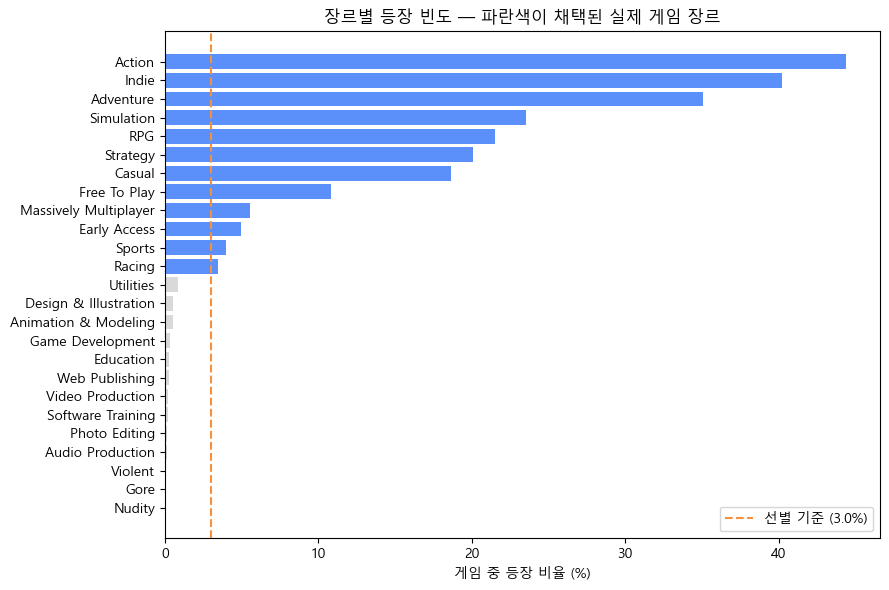

In [11]:
genre_counter = Counter([g for lst in game_df['genre_list'] for g in lst])
genre_freq = pd.Series(genre_counter).sort_values(ascending=False)
genre_freq_pct = genre_freq / n_games * 100

THRESHOLD_PCT = 3.0

plt.figure(figsize=(9, 6))
colors = ['#5B8FF9' if v >= THRESHOLD_PCT else '#D9D9D9' for v in genre_freq_pct.values]
plt.barh(genre_freq_pct.index[::-1], genre_freq_pct.values[::-1], color=colors[::-1])
plt.axvline(THRESHOLD_PCT, color='#F6903D', linestyle='--', label=f'선별 기준 ({THRESHOLD_PCT}%)')
plt.xlabel('게임 중 등장 비율 (%)')
plt.title('장르별 등장 빈도 — 파란색이 채택된 실제 게임 장르')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
real_genres = [g for g, c in genre_counter.most_common() if c / n_games >= THRESHOLD_PCT / 100]
excluded_genres = [g for g in genre_counter if g not in real_genres]

print(f"채택된 '실제 게임' 장르 ({len(real_genres)}개):")
print(real_genres)
print(f"\n제외된 비-게임 카테고리 ({len(excluded_genres)}개):")
print(excluded_genres)

채택된 '실제 게임' 장르 (12개):
['Action', 'Indie', 'Adventure', 'Simulation', 'RPG', 'Strategy', 'Casual', 'Free To Play', 'Massively Multiplayer', 'Early Access', 'Sports', 'Racing']

제외된 비-게임 카테고리 (13개):
['Audio Production', 'Utilities', 'Animation & Modeling', 'Design & Illustration', 'Photo Editing', 'Video Production', 'Education', 'Web Publishing', 'Game Development', 'Software Training', 'Violent', 'Gore', 'Nudity']


## 2. 핵심 태그 선별

태그는 423종으로 훨씬 많고, 다음 3단계 기준을 순서대로 적용해 선별함.

1. **장르와 중복되는 태그 제거** — 이미 genre 필드로 인코딩되므로 이중 반영 방지
2. **플레이 모드성 태그 제거** — `Singleplayer`, `Multiplayer`, `Co-op` 등은 '취향'이 아니라 '플레이 방식'이라 장르/태그 선호도와 성격이 다름 (별도 피처로 추후 다룰 수 있음)
3. **빈도 기반 Top-N 채택** — 남은 후보군의 빈도 분포를 보고 상위 N개(30개/50개)를 선택

In [14]:
tag_counter = Counter([t for lst in game_df['tag_list'] for t in lst])
print(f"전체 유니크 태그 수: {len(tag_counter)}")

# 1) 장르와 이름이 겹치는 태그 제거
real_genres_norm = {g.lower() for g in real_genres}
step1 = {t: c for t, c in tag_counter.items() if t.lower() not in real_genres_norm}
overlap_removed = set(tag_counter) - set(step1)
print(f"\n[1단계] 장르와 중복되는 태그 제거: {len(overlap_removed)}개 제거 -> {overlap_removed}")
print(f"남은 후보: {len(step1)}개")

전체 유니크 태그 수: 423

[1단계] 장르와 중복되는 태그 제거: 12개 제거 -> {'Casual', 'Action', 'Strategy', 'Sports', 'Indie', 'Racing', 'Free to Play', 'Early Access', 'Adventure', 'Simulation', 'RPG', 'Massively Multiplayer'}
남은 후보: 411개


In [15]:
# 2) 플레이 모드성 태그 제거
play_mode_tags = {'singleplayer', 'multiplayer', 'co-op', 'online co-op', 'pvp', 'online pvp',
                   'controller', 'local co-op', 'local multiplayer', 'mmo', 'split screen'}

step2 = {t: c for t, c in step1.items() if t.lower() not in play_mode_tags}
mode_removed = set(step1) - set(step2)
print(f"[2단계] 플레이 모드성 태그 제거: {len(mode_removed)}개 제거 -> {mode_removed}")
print(f"남은 후보: {len(step2)}개")

[2단계] 플레이 모드성 태그 제거: 9개 제거 -> {'Singleplayer', 'Co-op', 'Multiplayer', 'Split Screen', 'PvP', 'Local Co-Op', 'Controller', 'Online Co-Op', 'Local Multiplayer'}
남은 후보: 402개


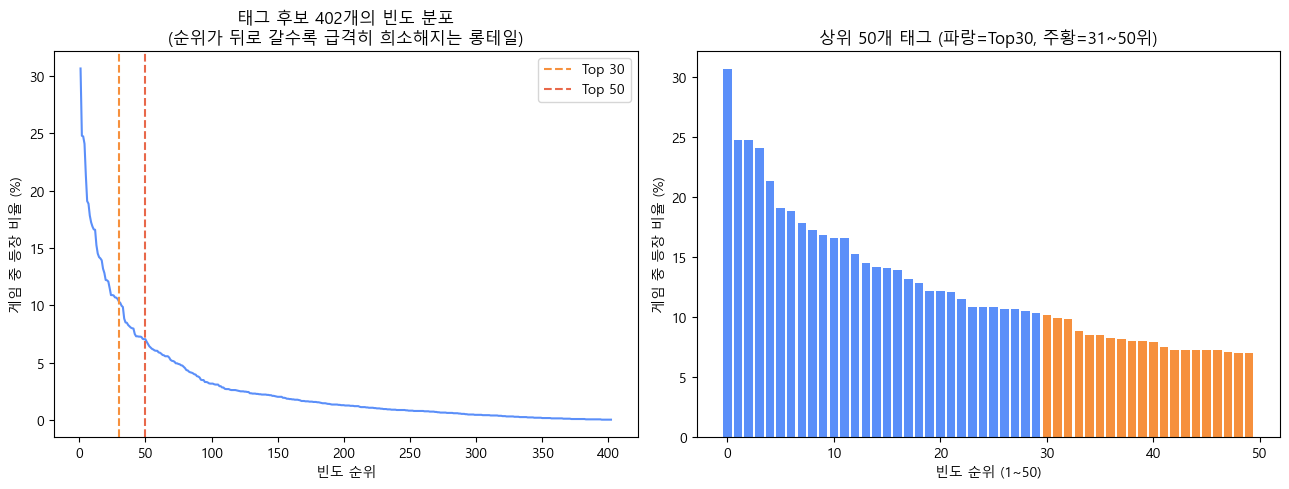

30위 태그 빈도: 10.3%
50위 태그 빈도: 7.0%
51위 태그부터는 급격히 빈도가 낮아짐(롱테일 진입) -> Top-N 컷오프가 합리적


In [16]:
# 3) 남은 후보군의 빈도 분포 확인 (Top-N 채택 근거)
candidate_freq = pd.Series(step2).sort_values(ascending=False)
candidate_freq_pct = candidate_freq / n_games * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 전체 후보 분포 - 롱테일 확인
axes[0].plot(range(1, len(candidate_freq_pct) + 1), candidate_freq_pct.values, color='#5B8FF9')
axes[0].axvline(30, color='#F6903D', linestyle='--', label='Top 30')
axes[0].axvline(50, color='#E8684A', linestyle='--', label='Top 50')
axes[0].set_xlabel('빈도 순위')
axes[0].set_ylabel('게임 중 등장 비율 (%)')
axes[0].set_title(f'태그 후보 {len(candidate_freq_pct)}개의 빈도 분포\n(순위가 뒤로 갈수록 급격히 희소해지는 롱테일)')
axes[0].legend()

# 상위 50개 막대
top50_preview = candidate_freq_pct.head(50)
colors = ['#5B8FF9' if i < 30 else '#F6903D' for i in range(50)]
axes[1].bar(range(50), top50_preview.values, color=colors)
axes[1].set_xlabel('빈도 순위 (1~50)')
axes[1].set_ylabel('게임 중 등장 비율 (%)')
axes[1].set_title('상위 50개 태그 (파랑=Top30, 주황=31~50위)')

plt.tight_layout()
plt.show()

print(f"30위 태그 빈도: {candidate_freq_pct.iloc[29]:.1f}%")
print(f"50위 태그 빈도: {candidate_freq_pct.iloc[49]:.1f}%")
print(f"51위 태그부터는 급격히 빈도가 낮아짐(롱테일 진입) -> Top-N 컷오프가 합리적")

In [17]:
TOP_N_SMALL = 30
TOP_N_LARGE = 50

selected_tags_30 = list(candidate_freq.index[:TOP_N_SMALL])
selected_tags_50 = list(candidate_freq.index[:TOP_N_LARGE])

print(f"[Top {TOP_N_SMALL}] 선별된 태그:")
print(selected_tags_30)
print(f"\n[Top {TOP_N_LARGE}] 선별된 태그 (31~50위 추가분):")
print(selected_tags_50[TOP_N_SMALL:])

[Top 30] 선별된 태그:
['Atmospheric', 'Open World', 'Story Rich', 'First-Person', '2D', 'Great Soundtrack', 'Funny', 'Sandbox', 'Shooter', 'Exploration', 'Third Person', '3D', 'Fantasy', 'FPS', 'Horror', 'Survival', 'Sci-fi', 'Puzzle', 'Difficult', 'Cute', 'Realistic', 'Gore', 'Character Customization', 'Anime', 'Building', 'Pixel Graphics', 'Family Friendly', 'Colorful', 'Management', 'Comedy']

[Top 50] 선별된 태그 (31~50위 추가분):
['Violent', 'Tactical', 'Psychological Horror', 'Female Protagonist', 'Relaxing', 'Classic', 'Action-Adventure', 'Crafting', 'Physics', 'Choices Matter', 'War', 'Moddable', 'Sexual Content', 'Action RPG', 'Dark', 'Arcade', 'Base Building', 'Retro', 'PvE', 'Resource Management']


## 3. 게임 단위 원핫 인코딩

선별된 장르(12개), 태그(30개/50개)에 대해 게임별 원핫 벡터를 생성함.

In [18]:
# 장르 원핫
for g in real_genres:
    game_df[f'genre__{g}'] = game_df['genre_list'].apply(lambda lst: int(g in lst))

# 태그 원핫 (50개 기준으로 만들고, 30개 버전은 컬럼 서브셋으로 사용)
for t in selected_tags_50:
    game_df[f'tag__{t}'] = game_df['tag_list'].apply(lambda lst: int(t in lst))

genre_cols = [f'genre__{g}' for g in real_genres]
tag_cols_30 = [f'tag__{t}' for t in selected_tags_30]
tag_cols_50 = [f'tag__{t}' for t in selected_tags_50]

print(f"게임 x 장르 원핫 shape: {game_df[genre_cols].shape}")
print(f"게임 x 태그(30) 원핫 shape: {game_df[tag_cols_30].shape}")
print(f"게임 x 태그(50) 원핫 shape: {game_df[tag_cols_50].shape}")
game_df[['appid', 'game_name'] + genre_cols + tag_cols_50].head()

게임 x 장르 원핫 shape: (3564, 12)
게임 x 태그(30) 원핫 shape: (3564, 30)
게임 x 태그(50) 원핫 shape: (3564, 50)


,appid,game_name,genre__Action,genre__Indie,genre__Adventure,genre__Simulation,genre__RPG,genre__Strategy,genre__Casual,genre__Free To Play,...,tag__War,tag__Moddable,tag__Sexual Content,tag__Action RPG,tag__Dark,tag__Arcade,tag__Base Building,tag__Retro,tag__PvE,tag__Resource Management
0,105600,Terraria,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1281930,tModLoader,1,1,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,582010,Monster Hunter: World,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,1623730,Palworld,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,504230,Celeste,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


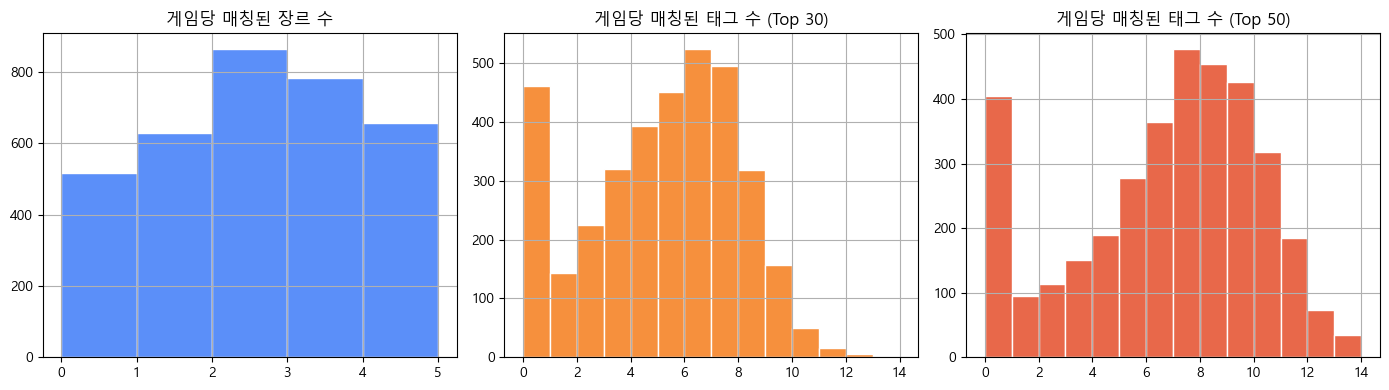

태그가 하나도 매칭 안 된 게임 (Top30 기준): 461개 (12.9%)
태그가 하나도 매칭 안 된 게임 (Top50 기준): 405개 (11.4%)


In [19]:
# 게임 하나당 선별된 장르/태그가 몇 개씩 매칭되는지 커버리지 확인 (선별이 너무 좁지 않은지 점검)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

game_df[genre_cols].sum(axis=1).hist(bins=range(0, 6), ax=axes[0], color='#5B8FF9', edgecolor='white')
axes[0].set_title('게임당 매칭된 장르 수')

game_df[tag_cols_30].sum(axis=1).hist(bins=range(0, 15), ax=axes[1], color='#F6903D', edgecolor='white')
axes[1].set_title('게임당 매칭된 태그 수 (Top 30)')

game_df[tag_cols_50].sum(axis=1).hist(bins=range(0, 15), ax=axes[2], color='#E8684A', edgecolor='white')
axes[2].set_title('게임당 매칭된 태그 수 (Top 50)')

plt.tight_layout()
plt.show()

print(f"태그가 하나도 매칭 안 된 게임 (Top30 기준): {(game_df[tag_cols_30].sum(axis=1)==0).sum()}개 "
      f"({(game_df[tag_cols_30].sum(axis=1)==0).mean()*100:.1f}%)")
print(f"태그가 하나도 매칭 안 된 게임 (Top50 기준): {(game_df[tag_cols_50].sum(axis=1)==0).sum()}개 "
      f"({(game_df[tag_cols_50].sum(axis=1)==0).mean()*100:.1f}%)")

## 4. 유저 선호도 벡터 생성

유저가 보유한 각 게임에 `log(playtime_hours + 1)`을 가중치로 곱해, 게임별 원핫 벡터를 합산.

$$\text{pref}_u = \sum_{g \in \text{owned}(u)} \log(1 + \text{playtime}_{u,g}) \times \text{onehot}(g)$$

플레이타임이 0인 게임은 `log(1)=0`이라 자연스럽게 선호도에 기여하지 않음 (아직 안 해본 게임이 취향을 나타내지 않는다는 가정과 일치).

In [20]:
onehot_cols = ['appid'] + genre_cols + tag_cols_50
merged = df[['steamid', 'appid', 'playtime_hours']].merge(game_df[onehot_cols], on='appid', how='left')
merged['log_playtime'] = np.log1p(merged['playtime_hours'])

print(f"결측 확인 (매칭 안 된 게임): {merged[genre_cols].isna().any(axis=1).sum()}건")
merged[genre_cols + tag_cols_50] = merged[genre_cols + tag_cols_50].fillna(0)

결측 확인 (매칭 안 된 게임): 0건


In [21]:
def build_pref_matrix(cols):
    weighted = merged[cols].values * merged['log_playtime'].values[:, None]
    tmp = pd.DataFrame(weighted, columns=cols)
    tmp['steamid'] = merged['steamid'].values
    return tmp.groupby('steamid').sum()

user_genre_pref = build_pref_matrix(genre_cols)
user_tag_pref_30 = build_pref_matrix(tag_cols_30)
user_tag_pref_50 = build_pref_matrix(tag_cols_50)

print(f"user_genre_pref: {user_genre_pref.shape}")
print(f"user_tag_pref_30: {user_tag_pref_30.shape}")
print(f"user_tag_pref_50: {user_tag_pref_50.shape}")
user_genre_pref.head()

user_genre_pref: (878, 12)
user_tag_pref_30: (878, 30)
user_tag_pref_50: (878, 50)


,genre__Action,genre__Indie,genre__Adventure,genre__Simulation,genre__RPG,genre__Strategy,genre__Casual,genre__Free To Play,genre__Massively Multiplayer,genre__Early Access,genre__Sports,genre__Racing
steamid,,,,,,,,,,,,
76561197960612825,88.395320,36.843884,69.723986,19.384872,47.025509,24.928063,0.000000,9.769919,0.000000,7.231488,7.138810,7.138810
76561197961222873,91.141229,29.831605,63.265680,17.045576,15.053334,3.091951,4.001315,15.810540,9.538134,0.000000,0.000000,0.000000
76561197961774441,105.430098,23.336859,56.031872,5.160204,73.731380,41.741554,0.000000,19.528534,6.465024,9.237578,0.000000,0.000000
76561197964052205,134.854535,26.973363,93.029118,33.987051,50.882421,4.414252,0.000000,16.194872,11.442799,8.637429,24.804405,16.060037
76561197964909627,73.423293,76.911920,35.785324,42.974549,89.724765,71.530726,39.311517,38.169368,0.000000,0.000000,0.000000,0.000000


### 예시: 한 유저의 선호도 벡터 살펴보기

샘플 유저: 76561197960612825


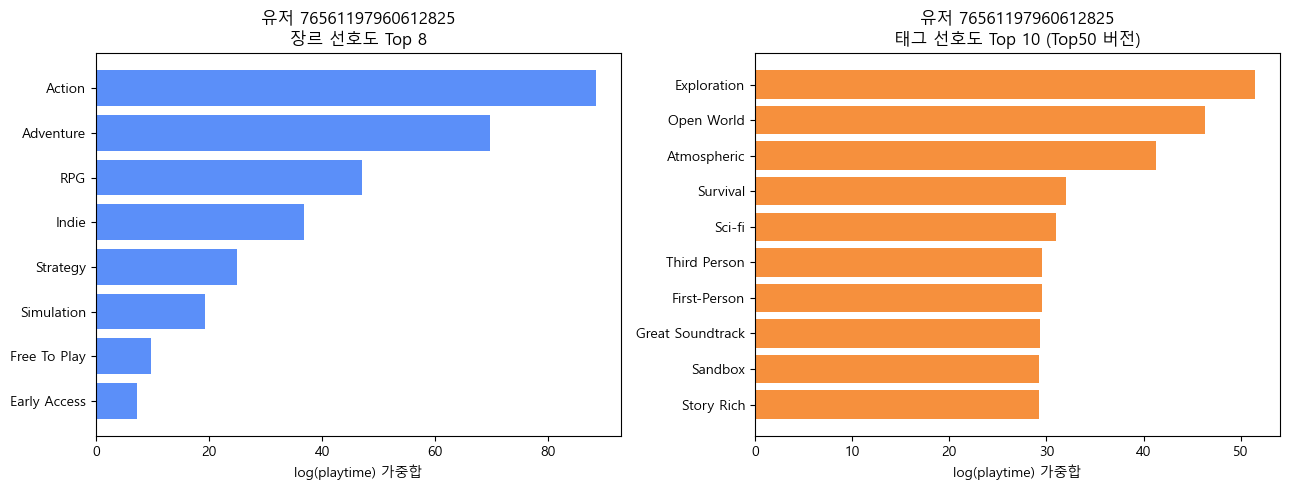

In [22]:
sample_user = user_genre_pref.index[0]
print(f"샘플 유저: {sample_user}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_genres = user_genre_pref.loc[sample_user].sort_values(ascending=False).head(8)
axes[0].barh([c.replace('genre__','') for c in top_genres.index][::-1], top_genres.values[::-1], color='#5B8FF9')
axes[0].set_title(f'유저 {sample_user}\n장르 선호도 Top 8')
axes[0].set_xlabel('log(playtime) 가중합')

top_tags = user_tag_pref_50.loc[sample_user].sort_values(ascending=False).head(10)
axes[1].barh([c.replace('tag__','') for c in top_tags.index][::-1], top_tags.values[::-1], color='#F6903D')
axes[1].set_title(f'유저 {sample_user}\n태그 선호도 Top 10 (Top50 버전)')
axes[1].set_xlabel('log(playtime) 가중합')

plt.tight_layout()
plt.show()

## 태그 5. Top 30 vs Top 50 비교

태그 개수를 늘렸을 때 유저 프로필이 얼마나 달라지는지 확인. 
(30개 버전은 50개 버전의 부분집합이므로, 상위 태그 선호도 자체는 동일하고 '표현할 수 있는 취향의 폭'만 넓어짐)

공통 태그(30개)에 대한 두 버전 간 선호도 값 차이 (0이어야 정상): 0.0000000000


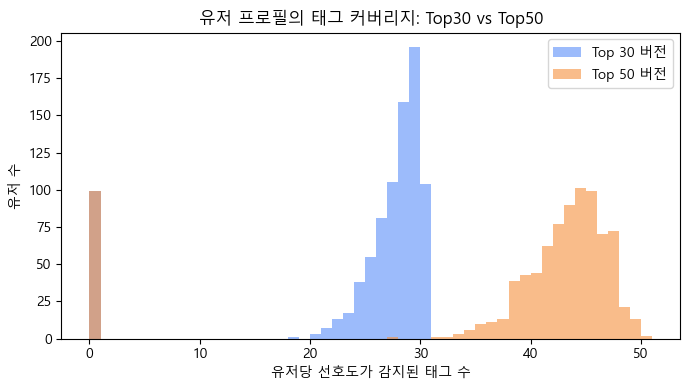

Top30 버전 - 유저당 평균 감지 태그 수: 24.4 / 30
Top50 버전 - 유저당 평균 감지 태그 수: 38.1 / 50


In [23]:
# 30개 버전 컬럼이 50개 버전에 포함되는지 확인 + 두 버전에서 공통 태그의 선호도 값이 동일한지 검증
common_cols = tag_cols_30
diff = (user_tag_pref_30[common_cols] - user_tag_pref_50[common_cols]).abs().values.max()
print(f"공통 태그(30개)에 대한 두 버전 간 선호도 값 차이 (0이어야 정상): {diff:.10f}")

# 벡터당 0이 아닌(선호도가 감지된) 태그 수 비교
nonzero_30 = (user_tag_pref_30 > 0).sum(axis=1)
nonzero_50 = (user_tag_pref_50 > 0).sum(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(nonzero_30, bins=range(0, 32), alpha=0.6, label='Top 30 버전', color='#5B8FF9')
plt.hist(nonzero_50, bins=range(0, 52), alpha=0.6, label='Top 50 버전', color='#F6903D')
plt.xlabel('유저당 선호도가 감지된 태그 수')
plt.ylabel('유저 수')
plt.title('유저 프로필의 태그 커버리지: Top30 vs Top50')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top30 버전 - 유저당 평균 감지 태그 수: {nonzero_30.mean():.1f} / 30")
print(f"Top50 버전 - 유저당 평균 감지 태그 수: {nonzero_50.mean():.1f} / 50")

## 6. 결과 저장

In [30]:
import os
os.makedirs('processed', exist_ok=True)

game_df[['appid', 'game_name'] + genre_cols + tag_cols_50].to_csv(
    'processed/game_onehot_features.csv', index=False)

user_genre_pref.to_csv('processed/user_genre_preference.csv')
user_tag_pref_30.to_csv('processed/user_tag_preference_top30.csv')
user_tag_pref_50.to_csv('processed/user_tag_preference_top50.csv')

print("저장 완료:")
print(" - game_onehot_features.csv       (게임 x 선별된 장르/태그 원핫)")
print(" - user_genre_preference.csv      (유저 x 12개 장르 선호도)")
print(" - user_tag_preference_top30.csv  (유저 x 30개 태그 선호도)")
print(" - user_tag_preference_top50.csv  (유저 x 50개 태그 선호도)")

저장 완료:
 - game_onehot_features.csv       (게임 x 선별된 장르/태그 원핫)
 - user_genre_preference.csv      (유저 x 12개 장르 선호도)
 - user_tag_preference_top30.csv  (유저 x 30개 태그 선호도)
 - user_tag_preference_top50.csv  (유저 x 50개 태그 선호도)
